In [1]:
# Basic Libraries
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple

# Sklearn: Model Selection & Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline

# Sklearn: Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             mean_absolute_error, mean_squared_error, mean_absolute_percentage_error,
                             r2_score, confusion_matrix)

# Sklearn: Regressors
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR, LinearSVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Sklearn: Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# Imbalanced-learn: Oversampling
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


In [2]:
#load the final cleaned dataset
df=pd.read_csv('cleaned_data.csv')

# Regression

In [ ]:
# label encoding for convert catagporical values to numeric

cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# devided data for train and test

x=df[['company_location','company_size','remote_ratio','job_title','employment_type','experience_level','work_year','employee_residence']]
y=df['salary_in_usd']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [4]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(x_train, y_train)

y_pred = xgb_model.predict(x_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / np.maximum(y_test, 1e-8))) * 100
print("XGBoost Regression Results:")
print("R² Score:", r2)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Percentage Error (MAPE):", mape, "%")

XGBoost Regression Results:
R² Score: 0.33442872762680054
Mean Absolute Error (MAE): 42082.57421875
Root Mean Squared Error (RMSE): 57711.73606815169
Mean Absolute Percentage Error (MAPE): 32.514774070554026 %


In [5]:
lr_model=LinearRegression()
lr_model.fit(x_train,y_train)
lr_model_prediction= lr_model.predict(x_test)

print("Mean Square Error :",mean_squared_error(y_test,lr_model_prediction))
print("Root Mean Squared Error (RMSE):", np.sqrt(mean_squared_error(y_test,lr_model_prediction)))
print("R² Score:", r2_score(y_test, lr_model_prediction))
print("Mean absolute Error :",mean_absolute_error(y_test,lr_model_prediction))
print("Intercept:",lr_model.intercept_)
mape = np.mean(np.abs((y_test - lr_model_prediction) / np.maximum(y_test, 1e-8))) * 100
print("Mean Absolute Percentage Error (MAPE):", mape, "%")


Mean Square Error : 4162560998.831336
Root Mean Squared Error (RMSE): 64517.91223242841
R² Score: 0.16818463727509214
Mean absolute Error : 47973.43974476254
Intercept: -2929710.3394377003
Mean Absolute Percentage Error (MAPE): 40.22184604670578 %


In [6]:

model = CatBoostRegressor(verbose=0)
model.fit(x_train, y_train)
pred = model.predict(x_test)

r2 = r2_score(y_test, pred)
mae = mean_absolute_error(y_test, pred)

mse = mean_squared_error(y_test, pred)
mape = (abs((y_test - pred) / y_test).mean()) * 100

print("CatBoost Regression Performance")
print("--------------------------------")
print(f"R² Score:        {r2:.4f}  ({r2*100:.2f}%)")
print(f"MAE:             {mae:.2f}")
print(f"MSE:             {mse:.2f}")
print(f"MAPE:            {mape:.2f}%")

CatBoost Regression Performance
--------------------------------
R² Score:        0.3355  (33.55%)
MAE:             42092.61
MSE:             3325039838.92
MAPE:            32.58%


In [ ]:
svr_model = make_pipeline(
    StandardScaler(),
    LinearSVR(
        C=1.0,
        max_iter=5000,
        loss="squared_epsilon_insensitive",
        epsilon=0.1,
        random_state=42
    )
)

svr_model.fit(x_train, y_train)
y_pred = svr_model.predict(x_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
print("LinearSVR Model Performance:")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape*100:.2f}%")


LinearSVR Model Performance:
R² Score: 0.1682
RMSE: 57711.74
MAE: 47973.20
MAPE: 40.22%


In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(x_train, y_train)
y_pred = rf_model.predict(x_test)

print("RandomForest Regressor Performance:")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred)*100:.2f}%")

RandomForest Regressor Performance:
R² Score: 0.3308
MAE: 42119.86
RMSE: 57867.25
MAPE: 32.51%


# Classification

[INFO] Loading dataset...
Dataset shape: (63988, 8), Target shape: (63988,)

=== PLOTTING EDA ===


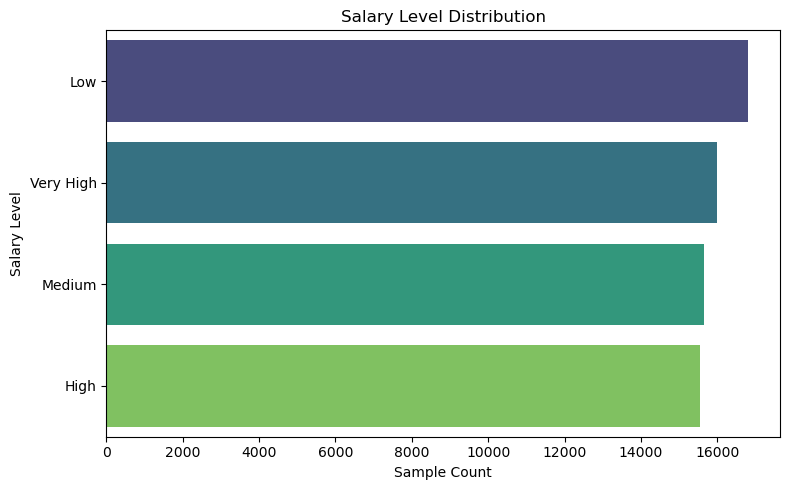

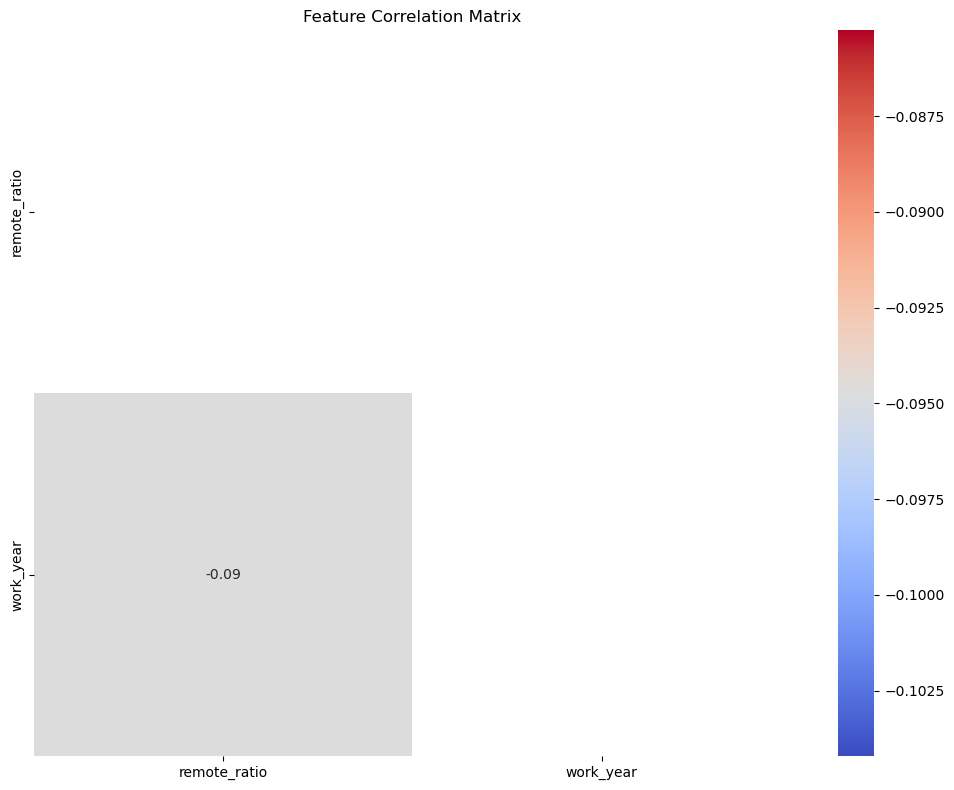


=== MODEL: XGBoost + OVERSAMPLER: none ===
CV Accuracy: 46.42% (+/- 0.38%)
Test Accuracy : 46.27%
Weighted F1  : 0.4579
Training Time: 1.19s


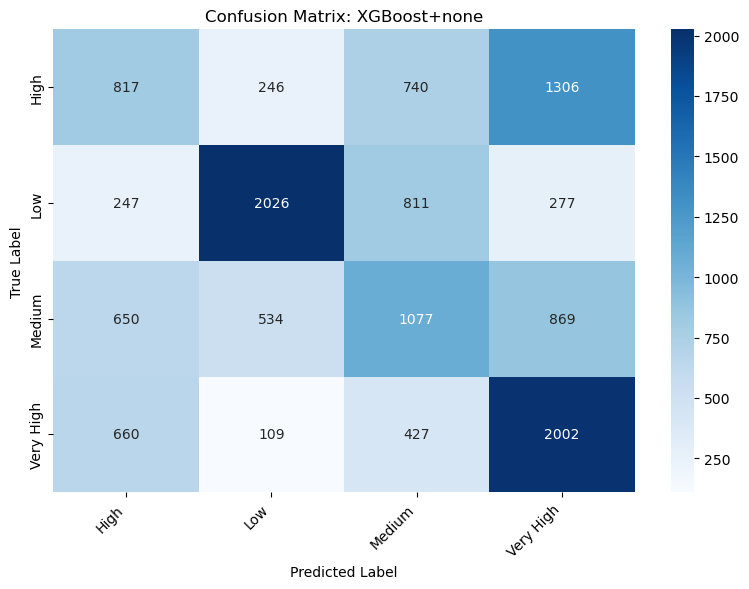

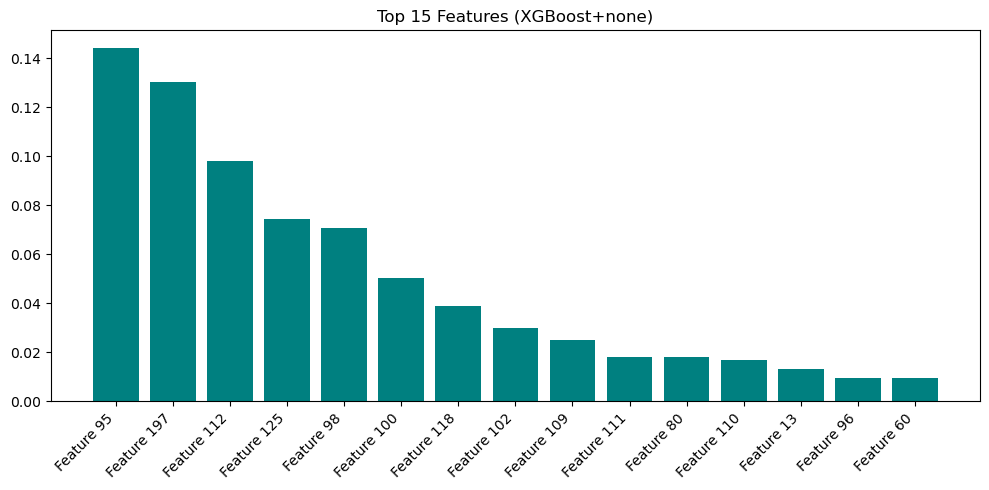


=== MODEL: RandomForest + OVERSAMPLER: none ===
CV Accuracy: 46.24% (+/- 0.30%)
Test Accuracy : 45.95%
Weighted F1  : 0.4523
Training Time: 14.07s


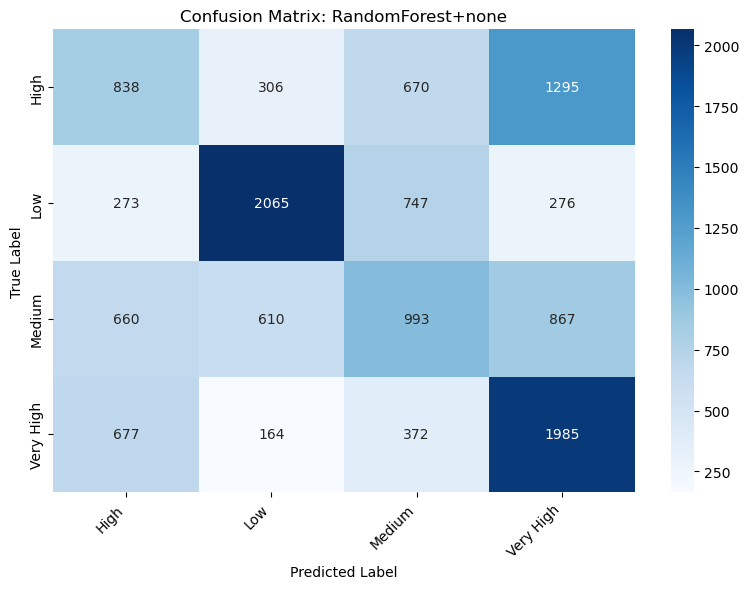

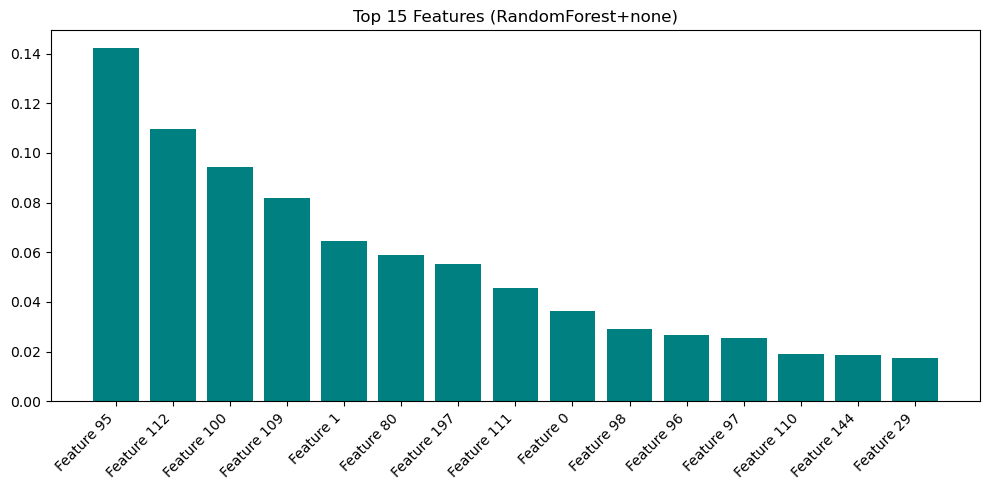


=== MODEL: DecisionTree + OVERSAMPLER: none ===
CV Accuracy: 46.12% (+/- 0.27%)
Test Accuracy : 45.95%
Weighted F1  : 0.4529
Training Time: 0.36s


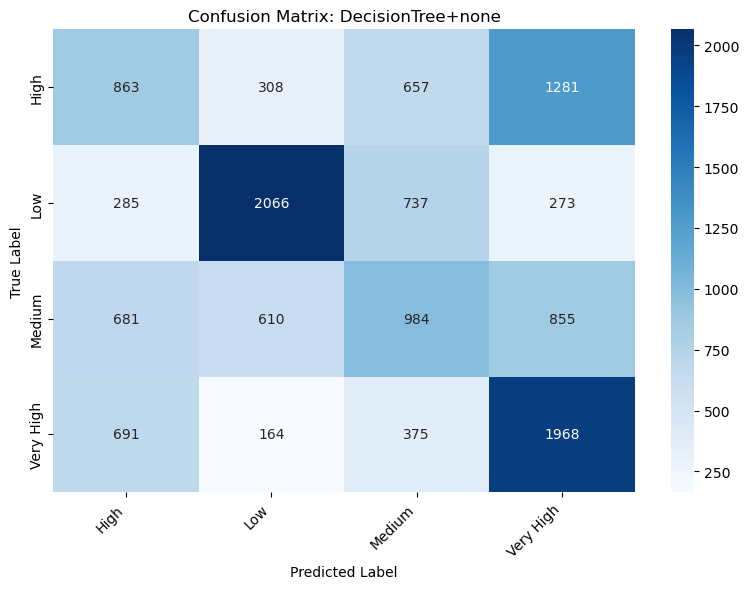

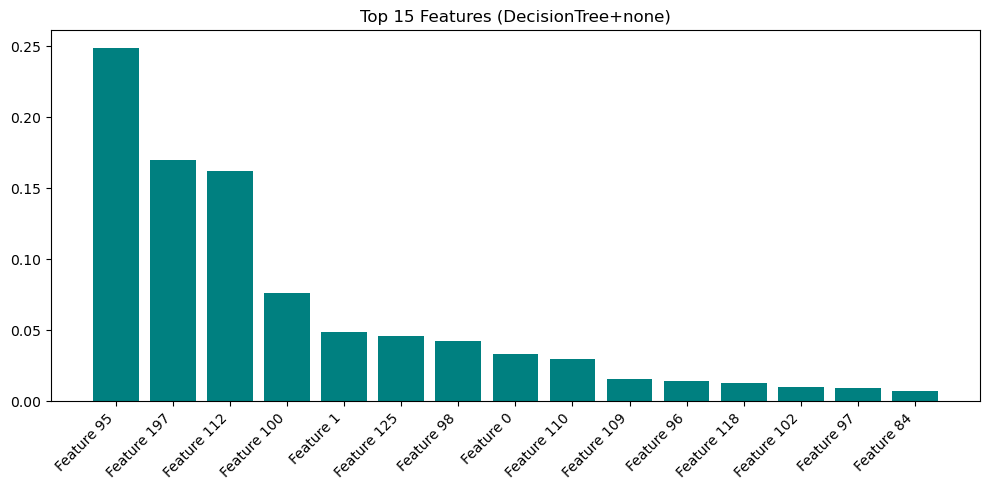


=== MODEL: LogisticRegression + OVERSAMPLER: none ===
CV Accuracy: 45.85% (+/- 0.24%)
Test Accuracy : 45.74%
Weighted F1  : 0.4270
Training Time: 0.77s


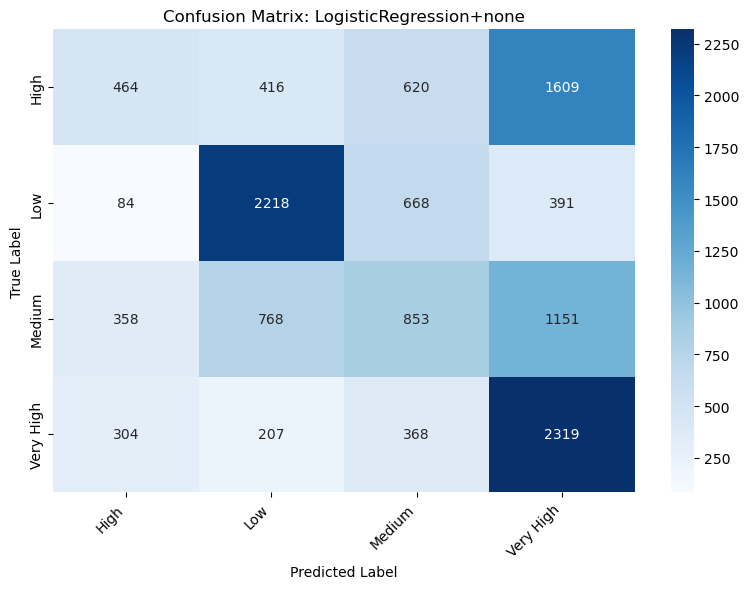


=== MODEL: XGBoost + OVERSAMPLER: SMOTE ===
CV Accuracy: 46.43% (+/- 0.30%)
Test Accuracy : 46.41%
Weighted F1  : 0.4598
Training Time: 13.70s


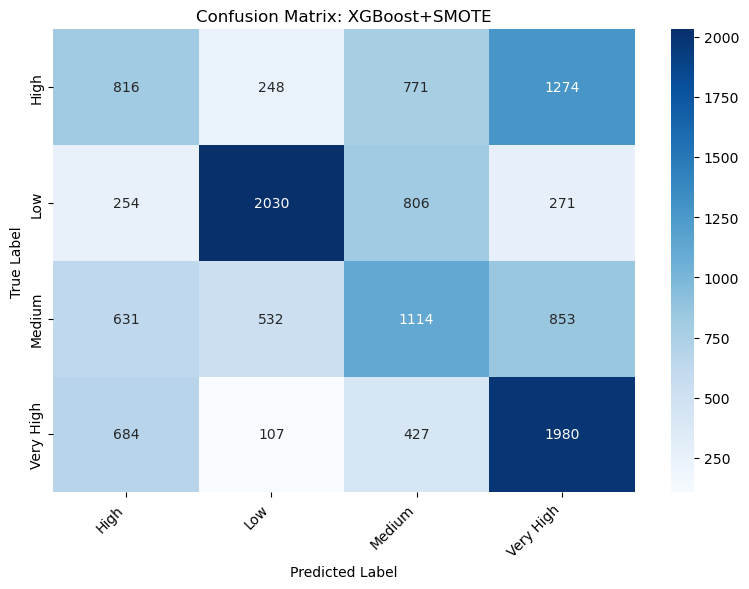

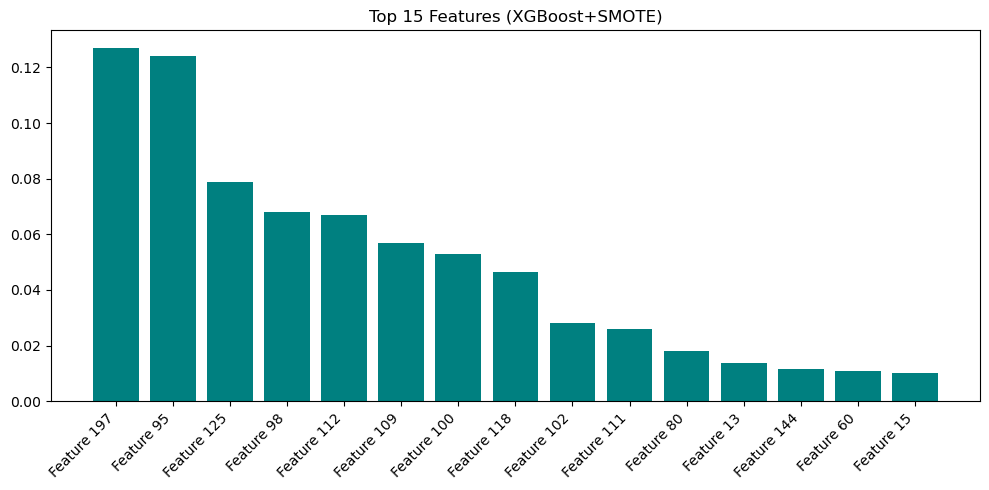


=== MODEL: RandomForest + OVERSAMPLER: SMOTE ===
CV Accuracy: 46.24% (+/- 0.20%)
Test Accuracy : 46.11%
Weighted F1  : 0.4575
Training Time: 27.22s


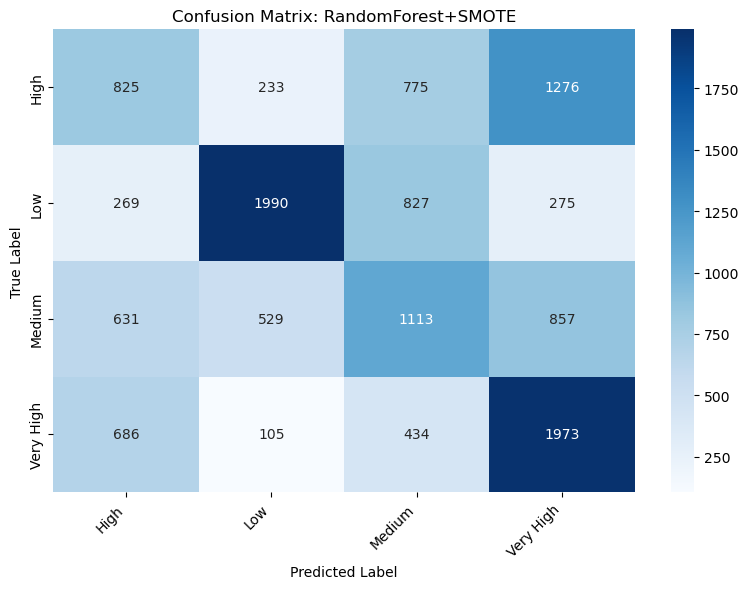

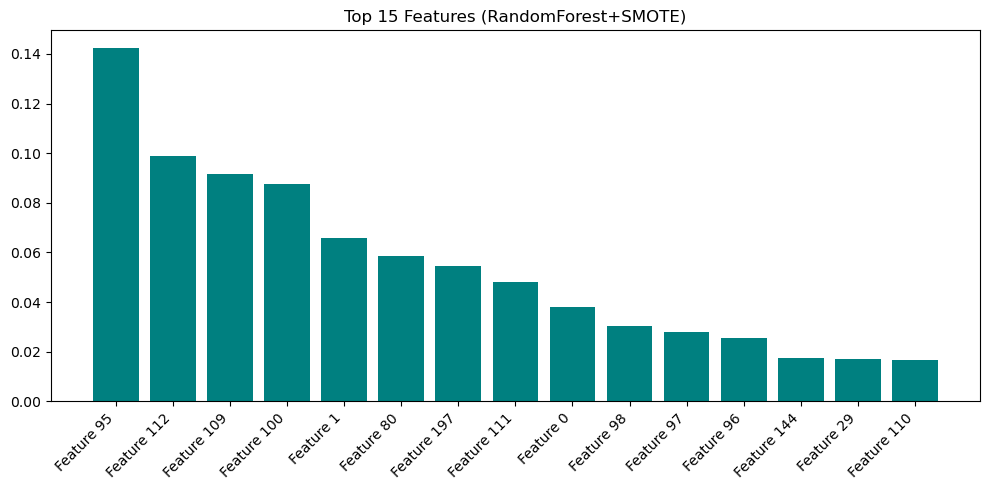


=== MODEL: DecisionTree + OVERSAMPLER: SMOTE ===
CV Accuracy: 46.12% (+/- 0.19%)
Test Accuracy : 46.13%
Weighted F1  : 0.4582
Training Time: 12.33s


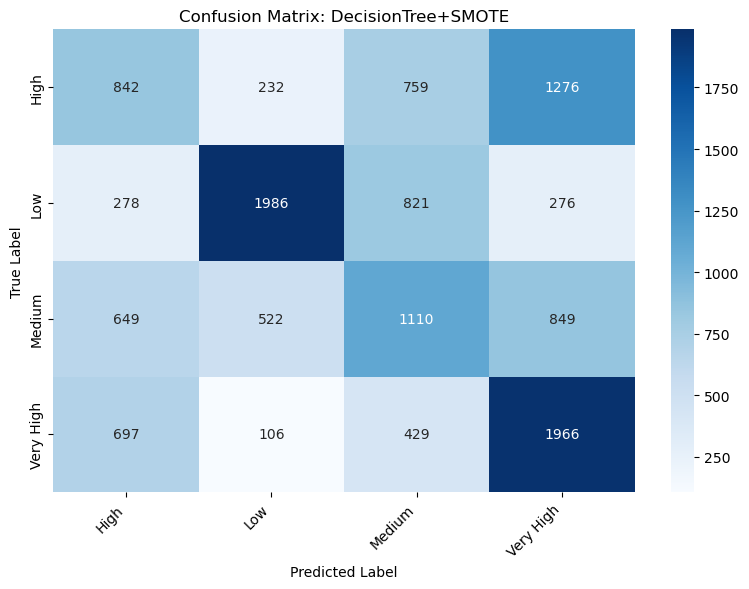

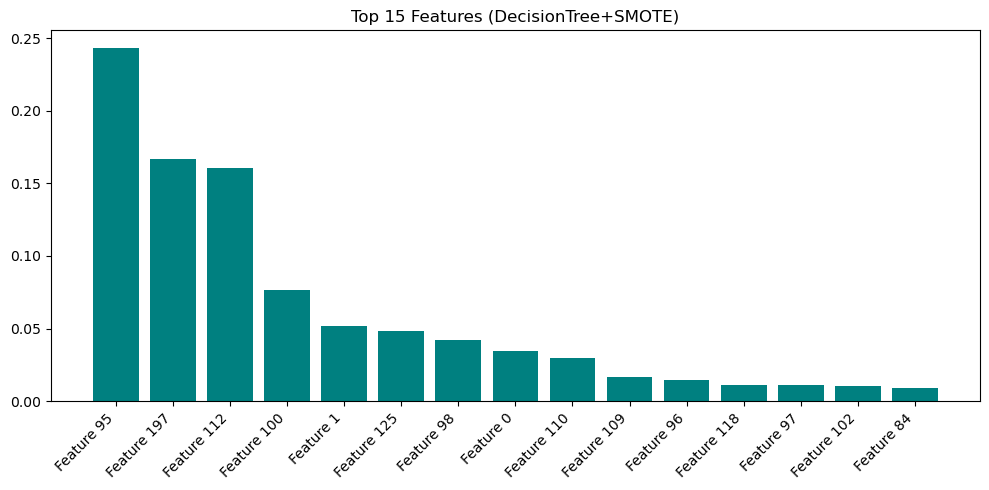


=== MODEL: LogisticRegression + OVERSAMPLER: SMOTE ===
CV Accuracy: 46.19% (+/- 0.38%)
Test Accuracy : 46.05%
Weighted F1  : 0.4574
Training Time: 12.38s


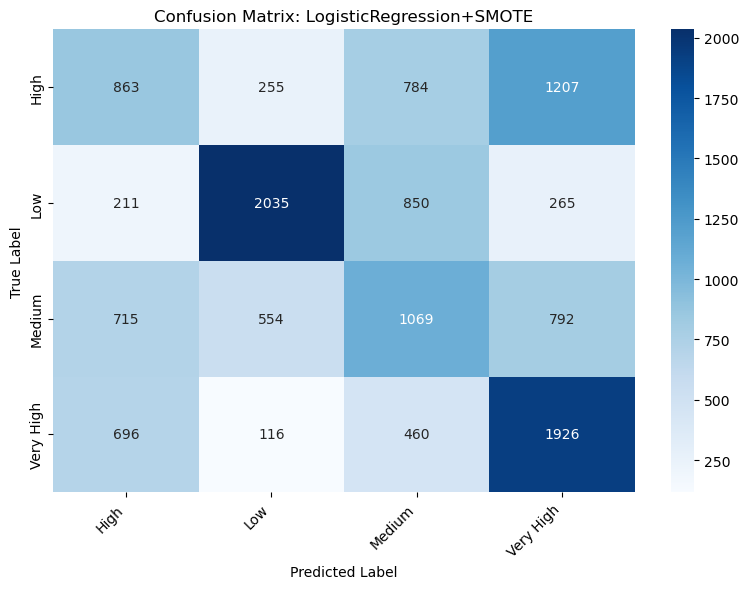


[SUCCESS] Multi-model salary classification with oversampling executed successfully.


In [ ]:

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False

warnings.filterwarnings("ignore")

BASE_PATH = "."  # current folder
class Config:
    file_path: str = os.path.join(BASE_PATH, "cleaned_data.csv")
    target_column: str = "salary_level"
    test_size: float = 0.2
    random_state: int = 42

def load_and_clean_data(cfg: Config) -> Tuple[pd.DataFrame, pd.Series]:
    if not os.path.exists(cfg.file_path):
        raise FileNotFoundError(f"Dataset not found at: {cfg.file_path}")

    df = pd.read_csv(cfg.file_path)

    # Drop rows with missing target
    df = df.dropna(subset=[cfg.target_column])
    df[cfg.target_column] = df[cfg.target_column].astype(str).str.strip()

    # Select only the features you want
    feature_cols = ['company_location','company_size','remote_ratio','job_title',
                    'employment_type','experience_level','work_year','employee_residence']
    X = df[feature_cols]
    y = df[cfg.target_column]

    return X, y

def plot_target_distribution(y: pd.Series):
    plt.figure(figsize=(8,5))
    sns.countplot(y=y, order=y.value_counts().index, palette='viridis')
    plt.title("Salary Level Distribution")
    plt.xlabel("Sample Count")
    plt.ylabel("Salary Level")
    plt.tight_layout()
    plt.show()

def plot_correlation_matrix(df: pd.DataFrame):
    numeric_df = df.select_dtypes(include=[np.number])
    corr = numeric_df.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, mask=mask, cmap='coolwarm', annot=True, fmt=".2f")
    plt.title("Feature Correlation Matrix")
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_test, y_pred, classes, model_name):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(f"Confusion Matrix: {model_name}")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

def plot_feature_importance(pipeline, X_train, model_name):
    model = pipeline.named_steps.get('classifier', pipeline.named_steps.get('clf', None))
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1][:15]

        plt.figure(figsize=(10,5))
        plt.title(f"Top 15 Features ({model_name})")
        plt.bar(range(len(indices)), importances[indices], align='center', color='teal')
        plt.xticks(range(len(indices)), [f"Feature {i}" for i in indices], rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

def build_pipeline(X_train, model, oversampler=None):
    numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', Pipeline([('imputer', SimpleImputer(strategy='median')),
                              ('scaler', StandardScaler())]), numeric_features),
            ('cat', Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
                              ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_features)
        ]
    )

    if oversampler is None:
        return Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])
    else:
        return ImbPipeline([
            ('preprocessor', preprocessor),
            ('sampler', oversampler),
            ('classifier', model)
        ])

def run_pipeline():
    cfg = Config()
    print("[INFO] Loading dataset...")
    X, y = load_and_clean_data(cfg)
    print(f"Dataset shape: {X.shape}, Target shape: {y.shape}")

    # --- EDA ---
    print("\n=== PLOTTING EDA ===")
    plot_target_distribution(y)
    plot_correlation_matrix(X)

    # --- LABEL ENCODING ---
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    class_names = le.classes_

    # --- TRAIN-TEST SPLIT ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=cfg.test_size, stratify=y_encoded, random_state=cfg.random_state
    )

    # --- OVERSAMPLERS ---
    oversamplers = {
        "none": None,
        "SMOTE": SMOTE(random_state=cfg.random_state, k_neighbors=3),
    
    }

    # --- MULTIPLE MODELS ---
    models = {
        "XGBoost": XGBClassifier(n_estimators=100, eval_metric='mlogloss', n_jobs=1, random_state=cfg.random_state) if HAS_XGBOOST else None,
        "RandomForest": RandomForestClassifier(n_estimators=100, n_jobs=1, random_state=cfg.random_state),
        "DecisionTree": DecisionTreeClassifier(random_state=cfg.random_state),
        "LogisticRegression": LogisticRegression(max_iter=1000, solver='liblinear')
    }

    for sampler_name, sampler in oversamplers.items():
        for name, model in models.items():
            if model is None:
                continue
            print(f"\n=== MODEL: {name} + OVERSAMPLER: {sampler_name} ===")
            pipeline = build_pipeline(X_train, model, sampler)

            # Cross-validation with error handling
            cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=cfg.random_state)
            try:
                scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
                print(f"CV Accuracy: {scores.mean()*100:.2f}% (+/- {scores.std()*100:.2f}%)")
            except ValueError as e:
                if "No samples will be generated" in str(e):
                    print(f"[WARNING] Oversampler '{sampler_name}' failed due to too few samples. Skipping oversampling.")
                    pipeline = build_pipeline(X_train, model, oversampler=None)
                    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
                    print(f"CV Accuracy without oversampling: {scores.mean()*100:.2f}% (+/- {scores.std()*100:.2f}%)")
                else:
                    raise e

            # Train on full training set
            start_train = time.time()
            try:
                pipeline.fit(X_train, y_train)
            except ValueError as e:
                if "No samples will be generated" in str(e):
                    print(f"[WARNING] Oversampler '{sampler_name}' failed during fit. Training without oversampling.")
                    pipeline = build_pipeline(X_train, model, oversampler=None)
                    pipeline.fit(X_train, y_train)
                else:
                    raise e
            train_time = time.time() - start_train

            # Evaluate on test set
            y_pred = pipeline.predict(X_test)
            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average='weighted')
            print(f"Test Accuracy : {acc*100:.2f}%")
            print(f"Weighted F1  : {f1:.4f}")
            print(f"Training Time: {train_time:.2f}s")

            # Plots
            plot_confusion_matrix(y_test, y_pred, class_names, f"{name}+{sampler_name}")
            plot_feature_importance(pipeline, X_train, f"{name}+{sampler_name}")

    print("\n[SUCCESS] Multi-model salary classification with oversampling executed successfully.")

# Run the pipeline
if __name__ == "__main__":
    run_pipeline()

